In [1]:
import numpy as np
import pandas as pd

In [2]:
import anndata
import scanpy as sc
import scvelo as scv

In [3]:
import scvelo as scv
import multivelo as mv

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
num_comps = 9

In [6]:
data_outdir = 'processed_data/arm/'
model_outdir = 'modeling_results/arm/joint_arches/'+str(num_comps)+'_comps/'

In [7]:
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')
AA_result = sc.read_h5ad(model_outdir+'archvelo_result.h5ad')

In [8]:
lik_cutoff = 0.05
AA_result.var['velo_s_genes'] = AA_result.var['fit_likelihood']>lik_cutoff
AA_result.var['velo_s_norm_genes'] = AA_result.var['fit_likelihood']>lik_cutoff

In [9]:
celltype_name = 'coarse'

In [10]:
adat_full = anndata.read_h5ad('processed_data/2_clones/adata_rna.h5ad')

In [11]:
def map_klrg(x):
    if x == 'Klrg1+ eff':
        return 'Klrg1++ eff'
    else:
        return x
adat_full.obs['coarse'] = adat_full.obs['coarse'].map(map_klrg)
adat_full.obs['small_coarse'] = adat_full.obs['small_coarse'].map(map_klrg)

In [12]:
coarse = adat_full[AA_result.obs_names,:].obs['coarse']
small_coarse = adat_full[AA_result.obs_names,:].obs['small_coarse']

In [13]:
for dat in [adata_rna, AA_result]:
    dat.obs['coarse'] = coarse
    dat.obs['small_coarse'] = small_coarse

In [14]:
celltype_name = 'coarse'
np.random.seed(10)
num_clusts = len(adat_full.obs['coarse'].cat.categories)
pal = dict(zip(adat_full.obs['coarse'].cat.categories,
               list(np.array(sns.color_palette('husl', num_clusts))[np.random.choice(num_clusts,num_clusts, replace = False)])))

In [15]:
pal_small = pal.copy()
pal_small.pop('Prog')
pal_small['Ccr6- prog'] = sns.color_palette('rainbow', 2)[0]
pal_small['Ccr6+ prog'] = sns.color_palette('hls', 7)[1]

In [16]:
import os
fig_outdir = 'figures/arm/'
os.makedirs(fig_outdir, exist_ok = True)

computing velocity graph (using 1/128 cores)


  0%|          | 0/3707 [00:00<?, ?cells/s]

    finished (0:00:30) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


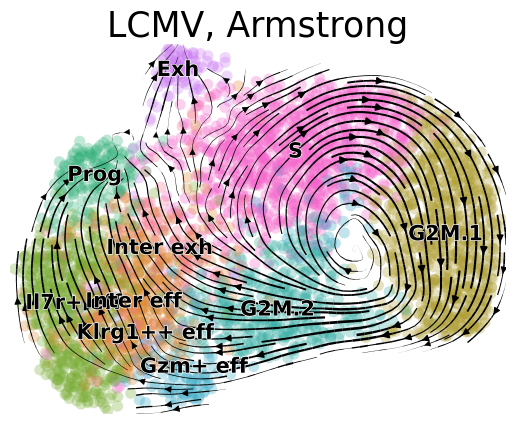

In [17]:
mv.velocity_graph(AA_result)
mv.latent_time(AA_result)
mv.velocity_embedding_stream(AA_result, 
                             #vkey = 'velo_s',
                             show=False, 
                             color = celltype_name, 
                             title = 'LCMV, Armstrong',
                            fontsize = 25,
                             palette = pal,
                            legend_fontsize = 15)
plt.savefig(fig_outdir+'AA_results.png', dpi = 600, transparent=True)
plt.savefig(fig_outdir+'AA_results.svg', dpi = 600, transparent=True)

# Transition probabilities

In [18]:
# recalculate with small number of neighbors for sharper transitions
n_pcs = 50
met = 'cosine'
n_neigh = 10
rand_st = 0

In [19]:
sc.pp.pca(AA_result, n_pcs,random_state = rand_st)
sc.pp.neighbors(AA_result, n_neighbors=n_neigh, n_pcs=n_pcs, 
                            metric = met,
                random_state = rand_st)
sc.tl.umap(AA_result, random_state = rand_st, spread = 0.5, min_dist = 0.8)

In [20]:
# recalculate with connectivities for correct normalization
avel = AA_result.copy()
mv.velocity_graph(avel, mode_neighbors = 'connectivities')
mv.latent_time(avel)

computing velocity graph (using 1/128 cores)


  0%|          | 0/3707 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)


In [21]:
ct_order = ['S',
 'G2M.1',
 'G2M.2',
 'Inter eff',
 'Klrg1++ eff',
 'Gzm+ eff',
 'Il7r+ eff',
 'Inter exh',
 'Exh',
 'Prog']

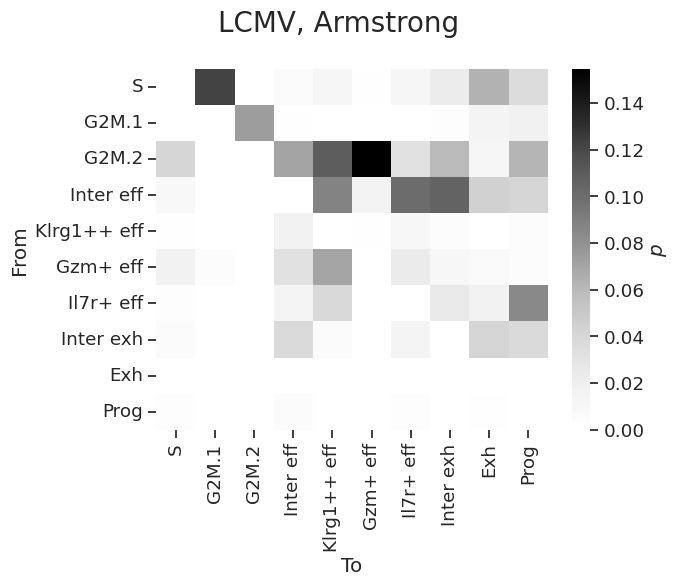

In [22]:
from scvelo.tl.transition_matrix import transition_matrix
tm = transition_matrix(
            avel,
            vkey='velo_s_norm',
            use_negative_cosines = True,
        ).todense()
tmm = pd.DataFrame(tm, index = avel.obs['coarse'],
             columns = avel.obs['coarse'])
tmm.index.names = ['coarse']
tmm.columns.names = ['coarse']
prbs = tmm.groupby('coarse').mean().T.groupby('coarse').mean()
prbs = prbs.div(prbs.sum(0),1)
for i in range(prbs.shape[0]):
    prbs.iloc[i,i] = 0
sns.set(style = 'ticks', font_scale = 1.2)
plt.figure(figsize = (7,6))
prbs = prbs.loc[ct_order, :].loc[:,ct_order]
import matplotlib as mpl
g = sns.heatmap((prbs*(prbs>0)).T, 
                cbar_kws={'label': "$p$"}, 
                cmap = 'Greys',
                #vmax = max_col, 
                vmin = 0)
plt.xlabel('To')
plt.ylabel('From')
# Adjust layout if needed
plt.subplots_adjust(top=0.9)
plt.suptitle('LCMV, Armstrong', fontsize = 20)
plt.tight_layout()
plt.savefig(fig_outdir+'trans_mat_arm_nonboundary.png', transparent = True, dpi = 400)
plt.savefig(fig_outdir+'trans_mat_arm_nonboundary.svg', transparent = True, dpi = 400)

In [23]:
prbs.to_csv('prbs_arm.csv')

In [24]:
ct_order = ['S',
 'G2M.1',
 'G2M.2',
 'Inter eff',
 'Klrg1++ eff',
 'Gzm+ eff',
 'Il7r+ eff',
 'Inter exh',
 'Exh',
 'Ccr6- prog',
 'Ccr6+ prog']

In [25]:
tm = transition_matrix(
            avel,
            vkey='velo_s_norm',
            use_negative_cosines = True,
        ).todense()
#tm = avel.uns['velo_s_norm_graph'].todense()
tmm = pd.DataFrame(tm, index = avel.obs['small_coarse'],
             columns = avel.obs['small_coarse'])
tmm.index.names = ['small_coarse']
tmm.columns.names = ['small_coarse']
prbs = tmm.groupby('small_coarse').mean().T.groupby('small_coarse').mean()
prbs = prbs.div(prbs.sum(0),1)
for i in range(prbs.shape[0]):
    prbs.iloc[i,i] = 0

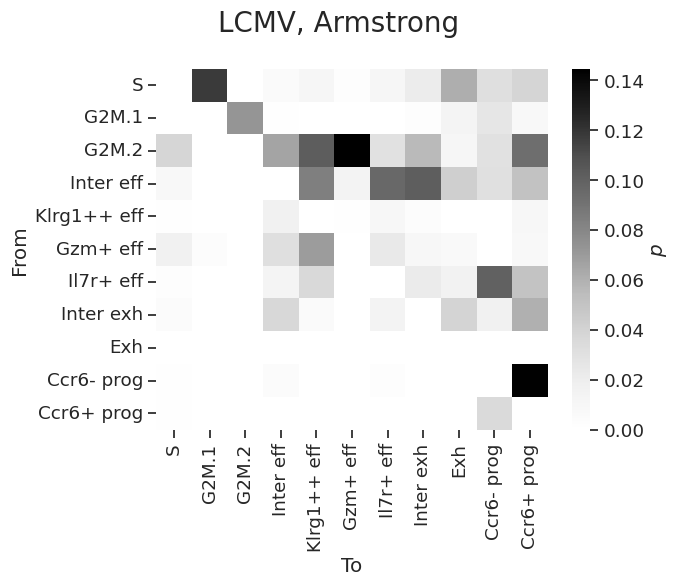

In [26]:
sns.set(style = 'ticks', font_scale = 1.2)
plt.figure(figsize = (7,6))
prbs = prbs.loc[ct_order, :].loc[:,ct_order]
import matplotlib as mpl
g = sns.heatmap((prbs*(prbs>0)).T, 
                cbar_kws={'label': "$p$"}, 
                cmap = 'Greys',
                #vmax = max_col, 
                vmin = 0)
plt.xlabel('To')
plt.ylabel('From')
# Adjust layout if needed
plt.subplots_adjust(top=0.9)
plt.suptitle('LCMV, Armstrong', fontsize = 20)
plt.tight_layout()
plt.savefig(fig_outdir+'trans_mat_arm_nonboundary_ccr6.png', transparent = True, dpi = 400)
plt.savefig(fig_outdir+'trans_mat_arm_nonboundary_ccr6.svg', transparent = True, dpi = 400)